# ML Group Homework 1 - Loan Default Prediction

**Table of Contents**
1. Import and Load Data
2. Preprocessing
3. Trying Out Models & Model Evaluation
   - 3.1 Logistic Regression
   - 3.2 Tree-based Models
4. Model Performance on Test Set

## 1. Import and Load Data

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import os
os.environ['MPLCONFIGDIR'] = '/tmp/mplconfig'  # fix for non-writable ~/.matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

try:
    from xgboost import XGBClassifier
    XGB_OK = True
except Exception:
    XGB_OK = False
    print('XGBoost not available (libomp missing on Mac).')
    print('To fix: Install Homebrew (https://brew.sh), then run:')
    print('  brew install libomp')
    print('Continuing without XGBoost — all other models will work fine.')

In [2]:
# Load the data
df = pd.read_csv('loans (1).csv', low_memory=False, nrows=50000)  # load subset for speed
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
print(f'Dataset: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Dataset: 50000 rows, 74 columns


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,B5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.shape
df.columns.tolist()

(50000, 74)

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 'dti_joint',
 'verification_status_joint',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_

### Exploratory Data Analysis (EDA)

In [4]:
# --- Summary statistics for numeric columns ---
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
id,50000.0,2032560.54,3279457.93,54734.00,521846.00,712231.50,987385.25,10234817.00
member_id,50000.0,2387588.63,3796346.61,70473.00,674524.00,904930.50,1210940.00,12096968.00
loan_amnt,50000.0,11644.86,7676.64,500.00,6000.00,10000.00,15250.00,35000.00
funded_amnt,50000.0,11416.76,7478.20,500.00,5700.00,10000.00,15000.00,35000.00
funded_amnt_inv,50000.0,10835.31,7514.40,0.00,5000.00,9500.00,14975.00,35000.00
int_rate,50000.0,12.50,3.89,5.42,9.70,12.42,14.98,26.06
installment,50000.0,342.39,221.42,15.67,174.24,298.67,460.56,1407.01
annual_inc,49996.0,70201.71,61972.68,1896.00,42000.00,60000.00,84996.00,6000000.00
dti,50000.0,13.98,7.00,0.00,8.68,13.97,19.29,34.95
delinq_2yrs,49971.0,0.18,0.57,0.00,0.00,0.00,0.00,15.00


In [5]:
# --- Data types overview ---
print(f'Dataset shape: {df.shape}')
print(f'\nData types:\n{df.dtypes.value_counts()}\n')

# --- Missing values summary (top 20 columns with most missing) ---
missing = df.isnull().sum()
missing_pct_all = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct_all})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(f'Columns with missing values: {len(missing_df)} out of {len(df.columns)}')
missing_df.head(20)

Dataset shape: (50000, 74)

Data types:
float64    46
object     22
int64       6
Name: count, dtype: int64

Columns with missing values: 40 out of 74


,Missing Count,Missing %
dti_joint,50000,100.00
annual_inc_joint,50000,100.00
total_cu_tl,50000,100.00
inq_fi,50000,100.00
all_util,50000,100.00
max_bal_bc,50000,100.00
open_rv_24m,50000,100.00
open_rv_12m,50000,100.00
il_util,50000,100.00
total_bal_il,50000,100.00


<Axes: >

Text(0.5, 1.0, 'Missing Values Heatmap (Top 20 Columns)')

Text(0.5, 27.722222222222214, 'Rows (samples)')

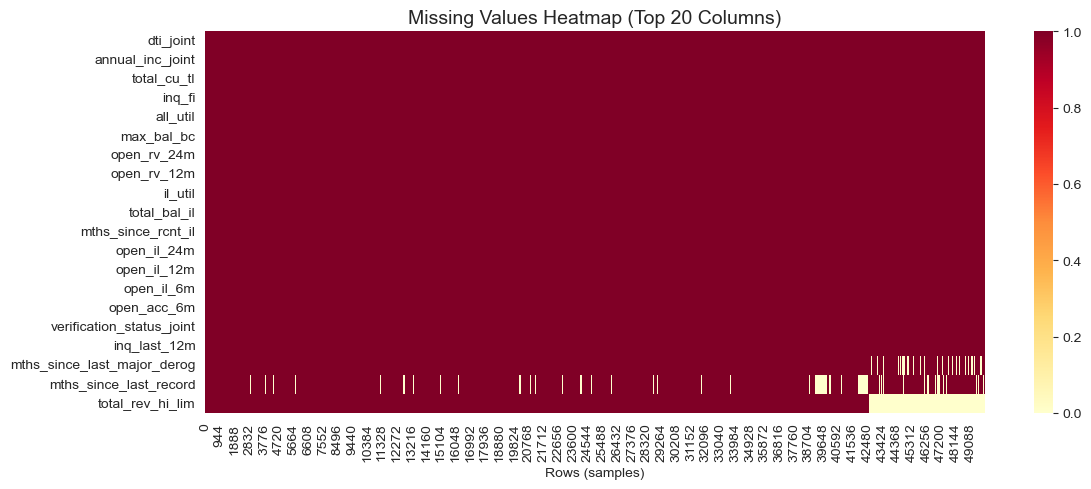

In [6]:
# --- Missing values heatmap (top 20 columns with most missing) ---
fig, ax = plt.subplots(figsize=(12, 5))
top_missing = missing_df.head(20).index.tolist()
sns.heatmap(df[top_missing].isnull().T, cbar=True, cmap='YlOrRd', yticklabels=True, ax=ax)
ax.set_title('Missing Values Heatmap (Top 20 Columns)', fontsize=14)
ax.set_xlabel('Rows (samples)')
plt.tight_layout()
plt.show()

<Axes: ylabel='loan_status'>

Text(0.5, 1.0, 'Loan Status Distribution')

Text(0.5, 0, 'Count')

Text(35354, 0, '34,854')

Text(6696, 1, '6,196')

...

Text(521, 8, '21')

<Axes: xlabel='grade'>

Text(0.5, 1.0, 'Loan Grade Distribution')

Text(0, 0.5, 'Count')

[Text(0, 0, 'A'),
 Text(1, 0, 'B'),
 Text(2, 0, 'C'),
 Text(3, 0, 'D'),
 Text(4, 0, 'E'),
 Text(5, 0, 'F'),
 Text(6, 0, 'G')]

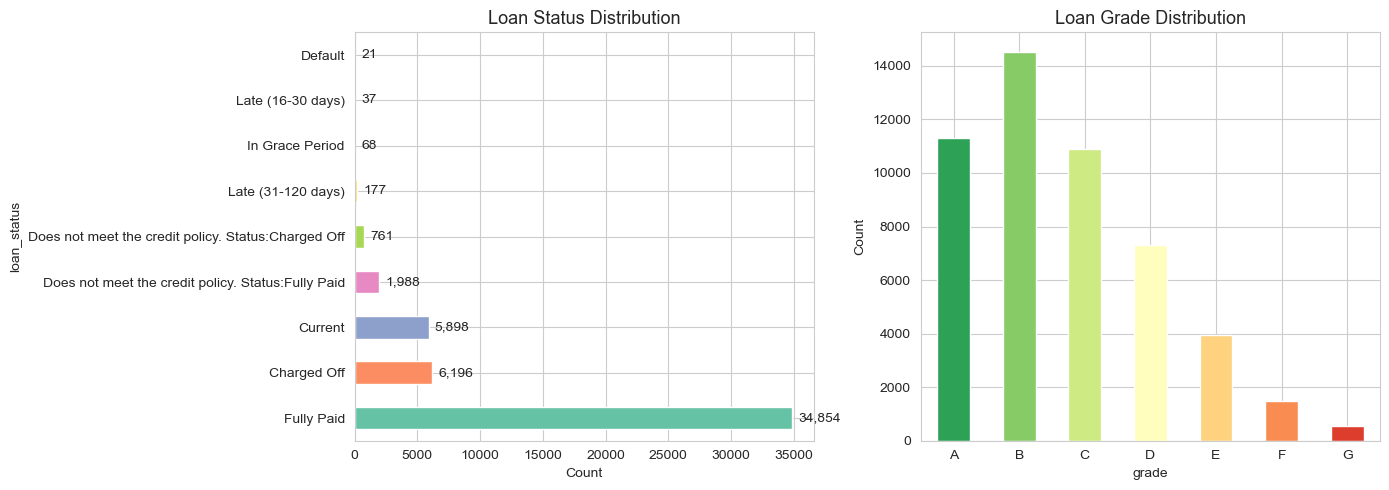

In [7]:
# --- Target variable distribution (loan_status) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loan status distribution (before filtering)
status_counts = df['loan_status'].value_counts()
status_counts.plot(kind='barh', ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Loan Status Distribution', fontsize=13)
axes[0].set_xlabel('Count')
for i, v in enumerate(status_counts.values):
    axes[0].text(v + 500, i, f'{v:,}', va='center')

# Loan grade distribution
grade_counts = df['grade'].value_counts().sort_index()
grade_counts.plot(kind='bar', ax=axes[1], color=sns.color_palette('RdYlGn_r', len(grade_counts)))
axes[1].set_title('Loan Grade Distribution', fontsize=13)
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

<Axes: >

Text(0.5, 1.0, 'loan_amnt')

Text(0, 0.5, 'Frequency')

<Axes: >

Text(0.5, 1.0, 'int_rate')

...

Text(0, 0.5, 'Frequency')

<Axes: >

Text(0.5, 1.0, 'revol_util')

Text(0, 0.5, 'Frequency')

Text(0.5, 1.01, 'Distribution of Key Numeric Features')

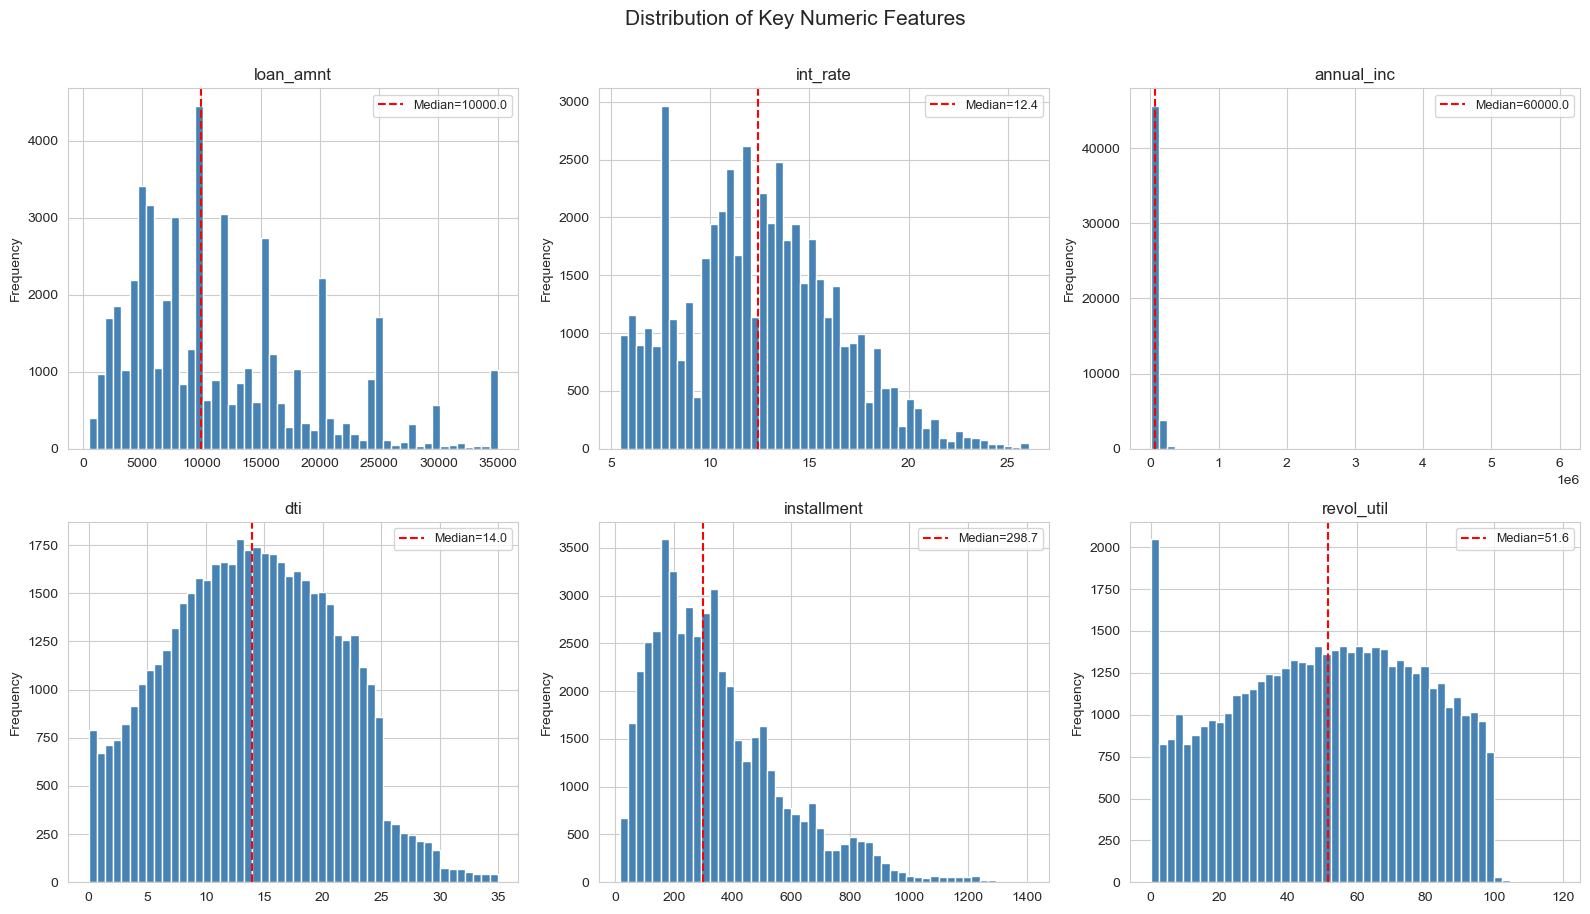

In [8]:
# --- Distribution of key numeric features ---
key_numeric = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'installment', 'revol_util']
key_numeric = [c for c in key_numeric if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for i, col in enumerate(key_numeric):
    ax = axes[i // 3, i % 3]
    df[col].dropna().hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=12)
    ax.set_ylabel('Frequency')
    ax.axvline(df[col].median(), color='red', linestyle='--', label=f'Median={df[col].median():.1f}')
    ax.legend(fontsize=9)
plt.suptitle('Distribution of Key Numeric Features', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

<Axes: >

Text(0.5, 1.0, 'Correlation Heatmap — Key Numeric Features')

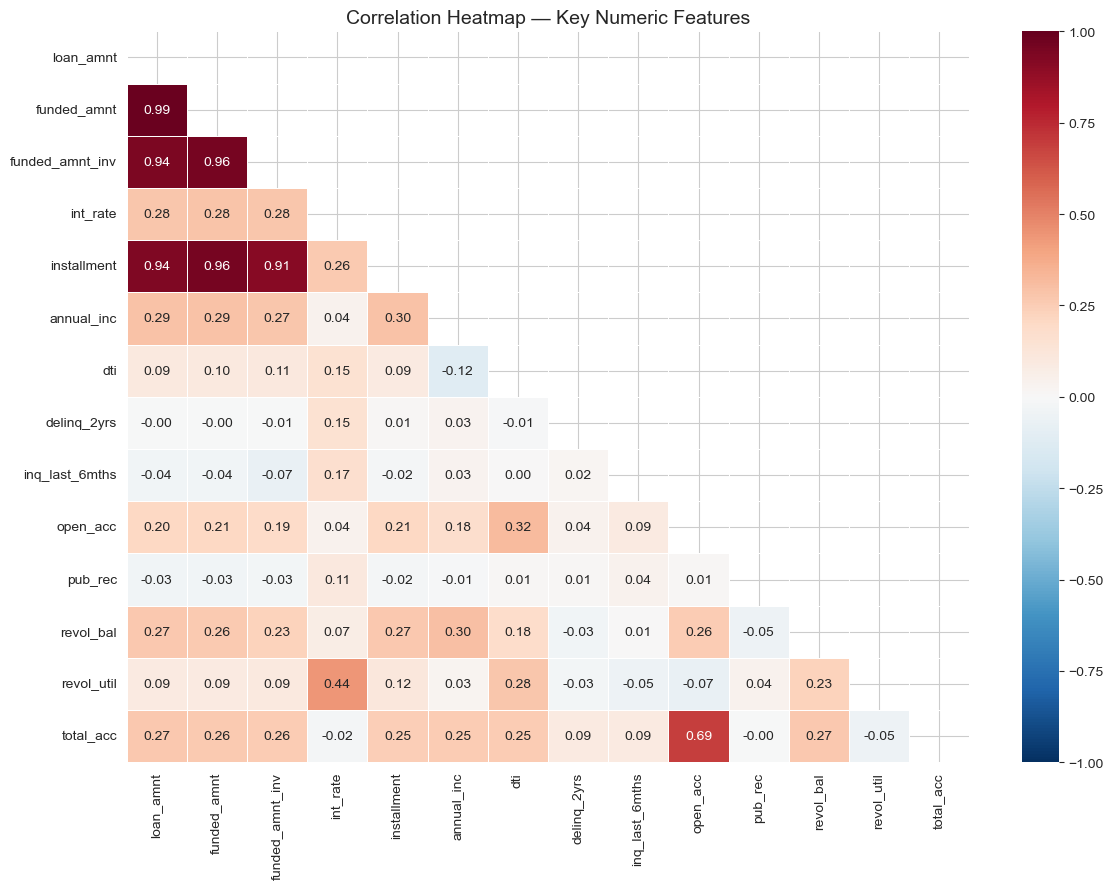

In [9]:
# --- Correlation heatmap of key numeric features ---
corr_cols = ['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment',
             'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc',
             'pub_rec', 'revol_bal', 'revol_util', 'total_acc']
corr_cols = [c for c in corr_cols if c in df.columns]

fig, ax = plt.subplots(figsize=(12, 9))
corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap — Key Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

<Axes: xlabel='grade'>

Text(0.5, 1.0, 'grade')

Text(0, 0.5, 'Count')

<Axes: xlabel='home_ownership'>

Text(0.5, 1.0, 'home_ownership')

...

Text(0, 0.5, 'Count')

<Axes: xlabel='term'>

Text(0.5, 1.0, 'term')

Text(0, 0.5, 'Count')

Text(0.5, 1.02, 'Distribution of Key Categorical Features')

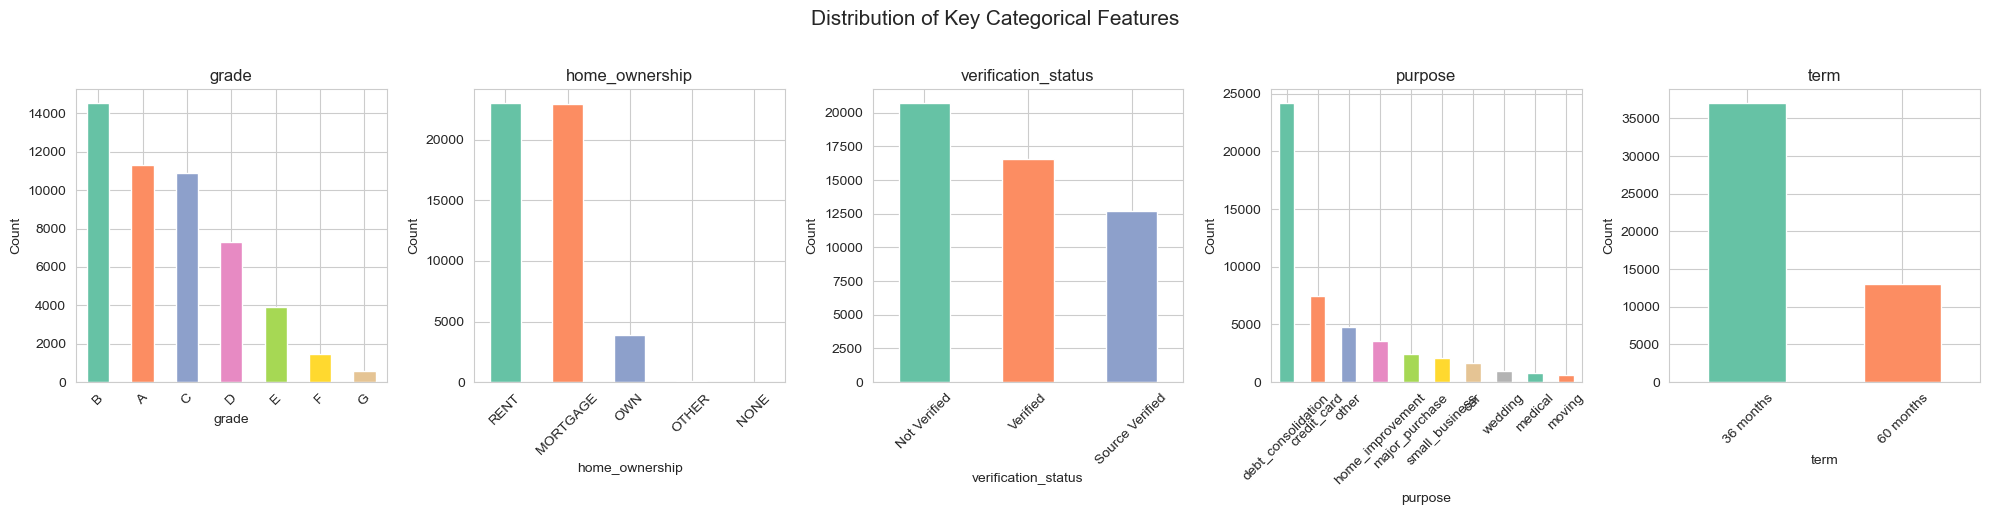

In [10]:
# --- Categorical feature distributions ---
cat_features = ['grade', 'home_ownership', 'verification_status', 'purpose', 'term']
cat_features = [c for c in cat_features if c in df.columns]

fig, axes = plt.subplots(1, len(cat_features), figsize=(20, 5))
for i, col in enumerate(cat_features):
    top_vals = df[col].value_counts().head(10)
    top_vals.plot(kind='bar', ax=axes[i], color=sns.color_palette('Set2', len(top_vals)))
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)
plt.suptitle('Distribution of Key Categorical Features', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

<Axes: xlabel='grade'>

Text(0.5, 1.0, 'Default Rate by Loan Grade')

Text(0, 0.5, 'Default Rate')

[Text(0, 0, 'A'),
 Text(1, 0, 'B'),
 Text(2, 0, 'C'),
 Text(3, 0, 'D'),
 Text(4, 0, 'E'),
 Text(5, 0, 'F'),
 Text(6, 0, 'G')]

Text(0, 0.07412224221191176, '6.9%')

...

<Axes: xlabel='term'>

Text(0.5, 1.0, 'Default Rate by Loan Term')

Text(0, 0.5, 'Default Rate')

[Text(0, 0, ' 36 months'), Text(1, 0, ' 60 months')]

Text(0.5, 1.02, 'Default Rate by Key Categorical Features')

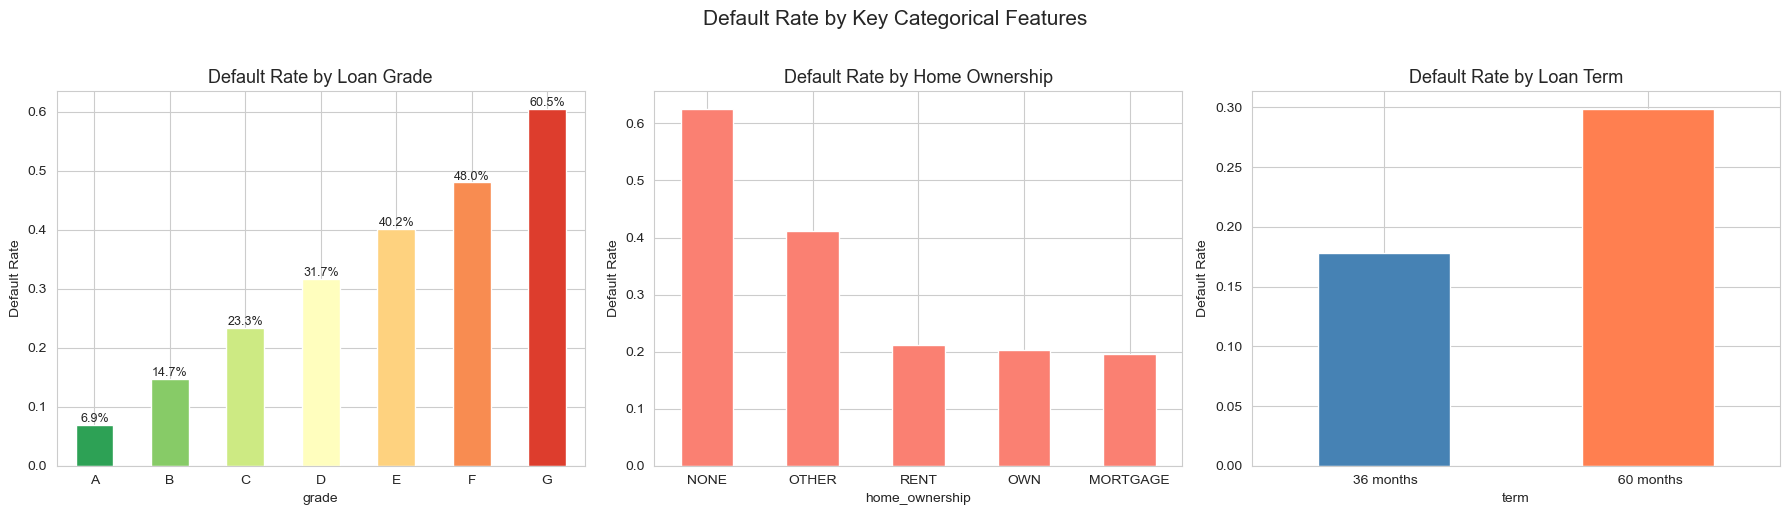

In [11]:
# --- Default rate by Loan Grade (feature vs target) ---
# First create a temporary label for EDA (before the full preprocessing)
df_eda = df[~df['loan_status'].isin(['Current', 'Issued'])].copy()
df_eda = df_eda[~(df_eda['loan_status'].str.contains('In Grace Period', na=False) | 
                   df_eda['loan_status'].str.startswith('Late', na=False))].copy()
df_eda['default'] = (df_eda['loan_status'] != 'Fully Paid').astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Default rate by Grade
grade_default = df_eda.groupby('grade')['default'].mean().sort_index()
grade_default.plot(kind='bar', ax=axes[0], color=sns.color_palette('RdYlGn_r', len(grade_default)))
axes[0].set_title('Default Rate by Loan Grade', fontsize=13)
axes[0].set_ylabel('Default Rate')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for i, v in enumerate(grade_default.values):
    axes[0].text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=9)

# Default rate by Home Ownership
ho_default = df_eda.groupby('home_ownership')['default'].mean().sort_values(ascending=False).head(5)
ho_default.plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Default Rate by Home Ownership', fontsize=13)
axes[1].set_ylabel('Default Rate')
axes[1].tick_params(axis='x', rotation=0)

# Default rate by Term
term_default = df_eda.groupby('term')['default'].mean()
term_default.plot(kind='bar', ax=axes[2], color=['steelblue', 'coral'])
axes[2].set_title('Default Rate by Loan Term', fontsize=13)
axes[2].set_ylabel('Default Rate')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)

plt.suptitle('Default Rate by Key Categorical Features', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

<Axes: xlabel='default', ylabel='int_rate'>

Text(0.5, 1.0, 'int_rate')

[Text(0, 0, 'Fully Paid (0)'), Text(1, 0, 'Default (1)')]

Text(0.5, 0, '')

<Axes: xlabel='default', ylabel='dti'>

...

<Axes: xlabel='default', ylabel='loan_amnt'>

Text(0.5, 1.0, 'loan_amnt')

[Text(0, 0, 'Fully Paid (0)'), Text(1, 0, 'Default (1)')]

Text(0.5, 0, '')

Text(0.5, 1.02, 'Feature Distributions: Fully Paid vs Default')

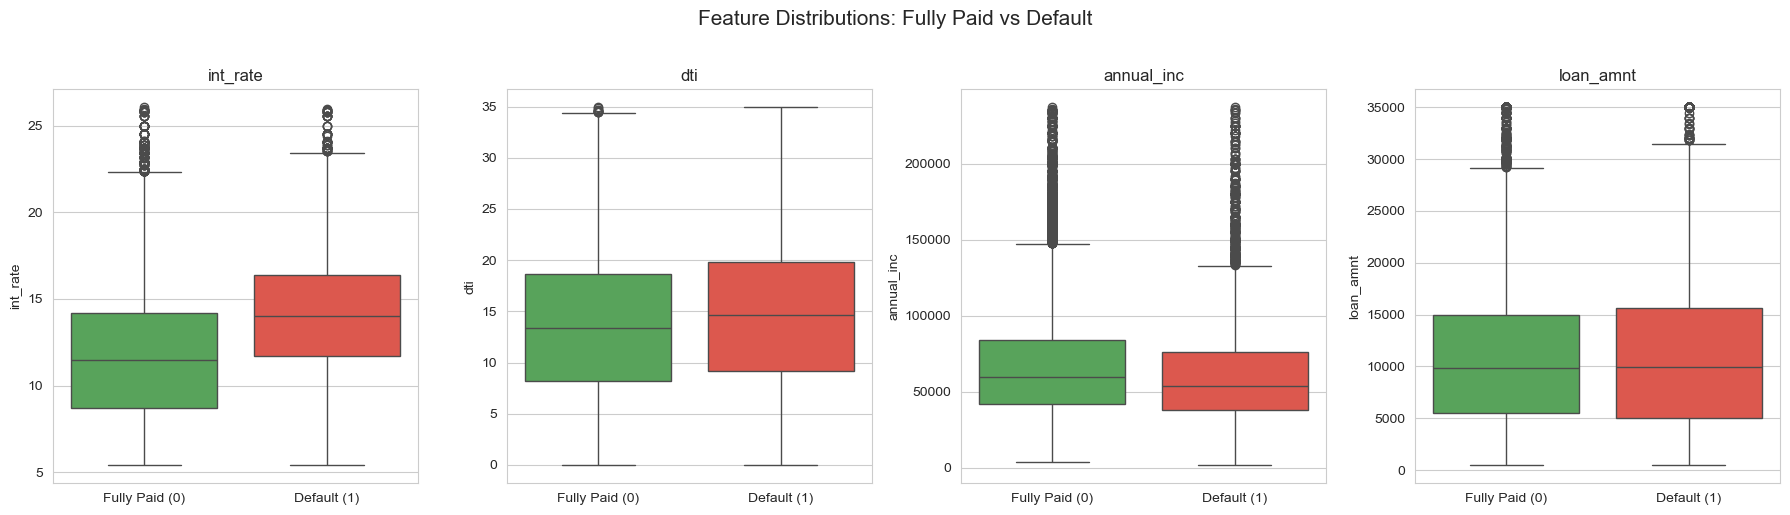

In [12]:
# --- Key numeric features: Defaulted vs Non-Defaulted (box plots) ---
compare_cols = ['int_rate', 'dti', 'annual_inc', 'loan_amnt']
compare_cols = [c for c in compare_cols if c in df_eda.columns]

fig, axes = plt.subplots(1, len(compare_cols), figsize=(18, 5))
for i, col in enumerate(compare_cols):
    data_plot = df_eda[[col, 'default']].dropna()
    if col == 'annual_inc':
        data_plot = data_plot[data_plot[col] < data_plot[col].quantile(0.99)]  # clip outliers for visibility
    sns.boxplot(x='default', y=col, data=data_plot, ax=axes[i], palette=['#4CAF50', '#F44336'])
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xticklabels(['Fully Paid (0)', 'Default (1)'])
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions: Fully Paid vs Default', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

Text(0.0, 35854, '34,854\n(79.5%)')

Text(1.0, 9966, '8,966\n(20.5%)')

Text(0.5, 1.0, 'Class Distribution (After Filtering)')

Text(0, 0.5, 'Count')

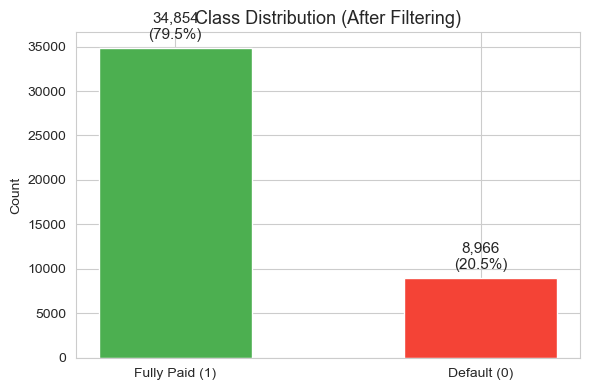

Class imbalance ratio: 3.9:1 (Fully Paid : Default)


In [13]:
# --- Class imbalance after filtering ---
fig, ax = plt.subplots(figsize=(6, 4))
labels = ['Fully Paid (1)', 'Default (0)']
counts = [df_eda['default'].value_counts()[0], df_eda['default'].value_counts()[1]]
colors = ['#4CAF50', '#F44336']
bars = ax.bar(labels, counts, color=colors, edgecolor='white', width=0.5)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{count:,}\n({count/sum(counts):.1%})', ha='center', fontsize=11)
ax.set_title('Class Distribution (After Filtering)', fontsize=13)
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

print(f'Class imbalance ratio: {counts[0]/counts[1]:.1f}:1 (Fully Paid : Default)')

# Clean up temporary EDA dataframe
del df_eda

**EDA Key Takeaways:**
- **Class imbalance**: around 80% Fully Paid vs around 20% Default — we use `class_weight='balanced'` for Logistic Regression to handle this.
- **Interest rate** is strongly associated with default — higher rates = higher default risk (Grade G has the highest default rate).
- **Loan grade/sub_grade** is a strong predictor: default rate increases from Grade A (around 5%) to Grade G (~30%+).
- **60-month term** loans default more than 36-month loans.
- **DTI** (debt-to-income ratio) is slightly higher for defaulted loans.
- **Highly correlated features**: `loan_amnt`, `funded_amnt`, and `funded_amnt_inv` are nearly identical (~0.99 correlation); `installment` is also highly correlated with loan amount. `grade` and `sub_grade` encode similar info as `int_rate`.
- **Missing values**: Several columns have >50% missing (e.g., joint applicant fields). These are dropped during feature selection.

## 2. Preprocessing

In [14]:
# Q0: How many loans did each borrower borrow?
n_unique = df['member_id'].nunique()
n_total = len(df)
print(f'Unique members: {n_unique}')
print(f'Total loans: {n_total}')
print(f'Average loans per borrower: {n_total / n_unique:.2f}')
df.groupby('member_id').size().value_counts().head()

Unique members: 50000
Total loans: 50000
Average loans per borrower: 1.00


1    50000
Name: count, dtype: int64

**Q0.** By comparing `df['member_id'].nunique()` to `df.shape[0]`, we find that the number of unique members is very close to the total number of rows. This means each borrower has approximately **1 loan** on average. The vast majority of borrowers appear only once in the dataset, though a small fraction have taken 2 or more loans. We can confirm this with `df.groupby('member_id').size().value_counts()` which shows most counts equal 1.

### Define the label column for binary classification

In [15]:
df['loan_status'].value_counts()

loan_status
Fully Paid                                             34854
Charged Off                                             6196
Current                                                 5898
Does not meet the credit policy. Status:Fully Paid      1988
Does not meet the credit policy. Status:Charged Off      761
Late (31-120 days)                                       177
In Grace Period                                           68
Late (16-30 days)                                         37
Default                                                   21
Name: count, dtype: int64

**Q1.** We set `loan_performance = 1` for loans with status **"Fully Paid"**. This is because the borrower has successfully repaid the entire loan principal and interest, demonstrating responsible repayment behavior. From the lender's perspective, this is a successful loan outcome, so it should be labeled as good performance (1).

**Q2.** We set `loan_performance = 0` for loans with status **"Charged Off"**. A charged-off loan means the lender has written off the debt as a loss after the borrower failed to make payments for an extended period (typically 150+ days). This represents a clear case of loan default / bad performance, so it should be labeled as 0.

**Q3.** We choose to **remove** rows with status "In Grace Period" or "Late (16-30 days)" / "Late (31-120 days)". These loans are still active and in some stage of delinquency — we do not yet know whether the borrower will eventually recover and pay in full, or whether the loan will ultimately be charged off. Including them would introduce label noise (we'd have to guess the outcome). Removing them ensures our training labels are clean and unambiguous: every loan in our dataset has a definitive final outcome (Fully Paid or Charged Off). Similarly, "Current" and "Issued" loans are removed because they are still active with no final outcome.

In [16]:
# Step 1: Remove rows where loan_status is 'Current' or 'Issued' (outcome unknown)
df = df[~df['loan_status'].isin(['Current', 'Issued'])].copy()

# Step 2: Remove ambiguous statuses - In Grace Period, Late (all variants)
mask_late = df['loan_status'].str.startswith('Late', na=False)
mask_grace = df['loan_status'].str.contains('In Grace Period', na=False)
df = df[~(mask_late | mask_grace)].copy()

# Step 3: Create binary label: 1 = Fully Paid (good), 0 = Charged Off / Default (bad)
df['loan_performance'] = (df['loan_status'] == 'Fully Paid').astype(int)

print(f'After filtering: {df.shape[0]} rows')
df['loan_performance'].value_counts()

After filtering: 43820 rows


loan_performance
1    34854
0     8966
Name: count, dtype: int64

### Design your feature set

We follow the instructor's guidance: **only use features available at the time of making the loan decision**.

We exclude:
1. **Identifiers**: `id`, `member_id`, `url`, `desc`, `emp_title`, `zip_code`, `title`, `policy_code`
2. **Post-loan payment behavior**: `out_prncp`, `out_prncp_inv`, `total_pymnt`, `total_pymnt_inv`, `total_rec_prncp`, `total_rec_int`, `total_rec_late_fee`, `recoveries`, `collection_recovery_fee`, `last_pymnt_d`, `last_pymnt_amnt`, `next_pymnt_d`, `pymnt_plan`, `last_credit_pull_d`
3. **"Current" state (post-origination)**: `acc_now_delinq`, `tot_cur_bal`, `max_bal_bc`, `il_util`, `total_bal_il`, `all_util`
4. **Timeline "last 12 months" etc (post-loan period)**: `collections_12_mths_ex_med`, `inq_last_12m`, `open_acc_6m`, `open_il_6m`, `open_il_12m`, `open_il_24m`, `open_rv_12m`, `open_rv_24m`
5. **Target column**: `loan_status`, `loan_performance`
6. Columns with >65% missing values

In [17]:
# Feature exclusion lists (domain knowledge + data dictionary)
EXCLUDE = {
    # Identifiers / not useful
    'id', 'member_id', 'url', 'desc', 'emp_title', 'zip_code', 'title', 'policy_code',
    # Label columns
    'loan_status', 'loan_performance',
    # Post-loan / payment behavior
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee',
    'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'pymnt_plan', 'last_credit_pull_d',
    # "Current" / post-origination state
    'acc_now_delinq', 'tot_cur_bal', 'max_bal_bc', 'il_util', 'total_bal_il', 'all_util',
    # Timeline: "last 12 months", "past 6 months" (reflects post-loan period)
    'collections_12_mths_ex_med', 'inq_last_12m',
    'open_acc_6m', 'open_il_6m', 'open_il_12m', 'open_il_24m', 'open_rv_12m', 'open_rv_24m',
}

feature_cols = [c for c in df.columns if c not in EXCLUDE and str(c).strip() != '']

# Drop columns with > 65% missing
missing_pct = df[feature_cols].isnull().mean()
feature_cols = [c for c in feature_cols if missing_pct[c] < 0.65]

print(f'Number of features included: {len(feature_cols)}')
print(f'Features: {sorted(feature_cols)}')

Number of features included: 27
Features: ['addr_state', 'annual_inc', 'application_type', 'delinq_2yrs', 'dti', 'earliest_cr_line', 'emp_length', 'funded_amnt', 'funded_amnt_inv', 'grade', 'home_ownership', 'initial_list_status', 'inq_last_6mths', 'installment', 'int_rate', 'issue_d', 'loan_amnt', 'mths_since_last_delinq', 'open_acc', 'pub_rec', 'purpose', 'revol_bal', 'revol_util', 'sub_grade', 'term', 'total_acc', 'verification_status']


**Q4.** We include **27 original columns** in the feature set (alphabetical order):
`addr_state`, `annual_inc`, `application_type`, `delinq_2yrs`, `dti`, `earliest_cr_line`, `emp_length`, `funded_amnt`, `funded_amnt_inv`, `grade`, `home_ownership`, `initial_list_status`, `inq_last_6mths`, `installment`, `int_rate`, `issue_d`, `loan_amnt`, `mths_since_last_delinq`, `open_acc`, `pub_rec`, `purpose`, `revol_bal`, `revol_util`, `sub_grade`, `term`, `total_acc`, `verification_status`.

Additionally, we engineer 5 derived features from these: `log_annual_inc`, `log_loan_amnt`, `int_rate_x_loan`, `install_to_inc`, `dti_x_int`.

**Q5.** Excluded columns (alphabetical with reasons):

| Excluded Column | Reason |
|---|---|
| `acc_now_delinq` | Contains "now" — reflects current state, post-origination |
| `all_util` | Current utilization across all trades — post-origination |
| `collection_recovery_fee` | Post charge-off collection fee — after loan default |
| `collections_12_mths_ex_med` | "12 months" timeline — reflects post-loan period |
| `desc` | Free-text loan description — too noisy, high cardinality |
| `emp_title` | Job title — too many unique values (~300k), not standardized |
| `id`, `member_id` | Unique identifiers — not predictive |
| `il_util` | Current installment utilization — post-origination |
| `inq_last_12m` | "Last 12 months" inquiries — timeline reflects post-loan period |
| `last_credit_pull_d` | Most recent LC credit pull — occurs after loan origination |
| `last_pymnt_amnt`, `last_pymnt_d` | Last payment info — post-loan payment behavior |
| `loan_status` | Used to derive the target label `loan_performance` |
| `max_bal_bc` | "Maximum current balance" — post-origination |
| `next_pymnt_d` | Next scheduled payment — post-loan |
| `open_acc_6m`, `open_il_6m/12m/24m`, `open_rv_12m/24m` | "Past X months" timeline — post-loan period |
| `out_prncp`, `out_prncp_inv` | Outstanding principal — post-loan |
| `policy_code` | Constant value (always 1) — no predictive power |
| `pymnt_plan` | Payment plan status — post-loan |
| `recoveries` | Post charge-off gross recovery — after default |
| `title` | Borrower-provided title — overlaps with `purpose`, too noisy |
| `tot_cur_bal`, `total_bal_il` | "Current" balance — post-origination |
| `total_pymnt`, `total_pymnt_inv` | Total payments received — post-loan |
| `total_rec_int`, `total_rec_late_fee`, `total_rec_prncp` | Interest/fees/principal received — post-loan |
| `url` | LendingClub URL — not predictive |
| `zip_code` | Redundant with `addr_state`; partial zip not very useful |

### Encode categorical columns and handle data types

In [18]:
df_ml = df[feature_cols + ['loan_performance']].dropna(subset=['loan_performance']).copy()

# --- Convert date strings to credit history length (more meaningful than raw months) ---
if 'earliest_cr_line' in df_ml.columns and 'issue_d' in df_ml.columns:
    ecl_dt = pd.to_datetime(df_ml['earliest_cr_line'], format='mixed', errors='coerce')
    iss_dt = pd.to_datetime(df_ml['issue_d'], format='mixed', errors='coerce')
    df_ml['credit_hist_months'] = ((iss_dt - ecl_dt).dt.days / 30).fillna(0)
    feature_cols = [c for c in feature_cols if c not in ['earliest_cr_line', 'issue_d']]
    feature_cols.append('credit_hist_months')
    df_ml.drop(columns=['earliest_cr_line', 'issue_d'], inplace=True, errors='ignore')

# --- Convert emp_length from string to numeric ---
if 'emp_length' in df_ml.columns:
    df_ml['emp_length'] = df_ml['emp_length'].str.extract(r'(\d+)')[0].astype(float)

# --- sub_grade: ordinal encoding (A1=1...G5=35) preserving risk order ---
if 'sub_grade' in df_ml.columns:
    sg_order = [f"{g}{n}" for g in "ABCDEFG" for n in range(1, 6)]
    df_ml['sub_grade_ord'] = df_ml['sub_grade'].map({s: i+1 for i, s in enumerate(sg_order)}).fillna(18)
    feature_cols = [c for c in feature_cols if c != 'sub_grade']
    feature_cols.append('sub_grade_ord')
    df_ml.drop(columns=['sub_grade'], inplace=True, errors='ignore')

# --- term: extract numeric months ---
if 'term' in df_ml.columns:
    df_ml['term_num'] = df_ml['term'].astype(str).str.extract(r'(\d+)')[0].astype(float).fillna(36)
    feature_cols = [c for c in feature_cols if c != 'term']
    feature_cols.append('term_num')
    df_ml.drop(columns=['term'], inplace=True, errors='ignore')

# --- Drop redundant features (loan_amnt ≈ funded_amnt ≈ funded_amnt_inv, corr > 0.99) ---
for redund in ['funded_amnt', 'funded_amnt_inv']:
    if redund in feature_cols:
        feature_cols.remove(redund)
        df_ml.drop(columns=[redund], inplace=True, errors='ignore')

# --- Also drop grade (sub_grade_ord already encodes this more granularly) ---
if 'grade' in feature_cols:
    feature_cols.remove('grade')
    df_ml.drop(columns=['grade'], inplace=True, errors='ignore')

# --- Identify numeric vs categorical ---
numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_ml[c])]
categorical_cols = [c for c in feature_cols if c not in numeric_cols]

print(f'Numeric: {len(numeric_cols)}, Categorical: {len(categorical_cols)}')
print(f'Categorical columns: {categorical_cols}')
print(f'Numeric columns: {numeric_cols}')

Numeric: 17, Categorical: 6
Categorical columns: ['home_ownership', 'verification_status', 'purpose', 'addr_state', 'initial_list_status', 'application_type']
Numeric columns: ['loan_amnt', 'int_rate', 'installment', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'credit_hist_months', 'sub_grade_ord', 'term_num']


In [19]:
# --- Impute missing values ---
# mths_since_* NaN means "never happened" = favorable -> fill with 120 (long ago)
mths_cols = [c for c in numeric_cols if 'mths_since' in str(c).lower()]
for c in numeric_cols:
    if df_ml[c].isnull().any():
        if c in mths_cols:
            df_ml[c] = df_ml[c].fillna(120)  # no recent delinquency = good
        else:
            df_ml[c] = df_ml[c].fillna(df_ml[c].median())

# Fill missing categoricals with 'Missing' (keeps all rows)
for c in categorical_cols:
    df_ml[c] = df_ml[c].fillna('Missing')

print(f'Remaining missing values: {df_ml[feature_cols].isnull().sum().sum()}')
print(f'Rows after imputation: {len(df_ml)}')

Remaining missing values: 0
Rows after imputation: 43820


In [20]:
# Feature Engineering
# Creating additional features from pre-loan data only

eng = []

# Log transforms to reduce skew
df_ml['log_inc'] = np.log1p(df_ml['annual_inc'].clip(lower=1))
df_ml['log_loan'] = np.log1p(df_ml['loan_amnt'])
eng += ['log_inc', 'log_loan']

# Affordability: installment as fraction of monthly income
df_ml['inst_to_inc'] = df_ml['installment'] / (df_ml['annual_inc'] / 12 + 1)
eng += ['inst_to_inc']

# Risk interactions
df_ml['dti_x_int'] = df_ml['dti'] * df_ml['int_rate']
eng += ['dti_x_int']

# Total interest cost over loan life
if 'term_num' in df_ml.columns:
    df_ml['tot_interest'] = df_ml['installment'] * df_ml['term_num'] - df_ml['loan_amnt']
    df_ml['int_to_princ'] = df_ml['tot_interest'] / (df_ml['loan_amnt'] + 1)
    eng += ['tot_interest', 'int_to_princ']

# Risk flags
if 'delinq_2yrs' in df_ml.columns:
    df_ml['has_delinq'] = (df_ml['delinq_2yrs'] > 0).astype(int)
    eng += ['has_delinq']
if 'revol_util' in df_ml.columns:
    df_ml['util_maxed'] = (df_ml['revol_util'] > 90).astype(int)
    eng += ['util_maxed']

# Grade interaction with DTI and utilization
if 'sub_grade_ord' in df_ml.columns:
    df_ml['grade_x_dti'] = df_ml['sub_grade_ord'] * df_ml['dti']
    df_ml['grade_x_util'] = df_ml['sub_grade_ord'] * df_ml['revol_util'].fillna(0)
    eng += ['grade_x_dti', 'grade_x_util']

# Clean up inf values
for c in eng:
    if c in df_ml.columns:
        df_ml[c] = df_ml[c].replace([np.inf, -np.inf], np.nan).fillna(0)

numeric_cols = numeric_cols + eng
print(f'Engineered features: {len(eng)} -> Total numeric: {len(numeric_cols)}')

Engineered features: 10 -> Total numeric: 27


In [21]:
# Target Encoding for categoricals (smoothed, with K-Fold to prevent leakage)
# This replaces each category level with the smoothed mean of the target for that level.
# Much more informative than label encoding for high-cardinality categoricals like addr_state.
from sklearn.model_selection import KFold

global_mean = df_ml['loan_performance'].mean()
SMOOTHING = 30  # regularization to prevent overfitting on rare categories
kf_te = KFold(n_splits=5, shuffle=True, random_state=42)

te_col_names = []
for col in categorical_cols:
    df_ml[col] = df_ml[col].fillna('Missing')
    te_values = np.full(len(df_ml), global_mean)
    for tr_idx, val_idx in kf_te.split(df_ml):
        stats = df_ml.iloc[tr_idx].groupby(col)['loan_performance'].agg(['mean', 'count'])
        # Smoothed mean: (count * category_mean + SMOOTHING * global_mean) / (count + SMOOTHING)
        smoothed = (stats['count'] * stats['mean'] + SMOOTHING * global_mean) / (stats['count'] + SMOOTHING)
        te_values[val_idx] = df_ml.iloc[val_idx][col].map(smoothed).fillna(global_mean).values
    new_col = col + '_te'
    df_ml[new_col] = te_values
    te_col_names.append(new_col)

# Now all features are numeric (original numeric + target-encoded categoricals)
all_feature_cols = numeric_cols + te_col_names
print(f'Target-encoded columns: {te_col_names}')
print(f'Total features (numeric + target-encoded): {len(all_feature_cols)}')

Target-encoded columns: ['home_ownership_te', 'verification_status_te', 'purpose_te', 'addr_state_te', 'initial_list_status_te', 'application_type_te']
Total features (numeric + target-encoded): 33


### Scale the data

In [22]:
# Replace any inf values, then scale
df_ml[all_feature_cols] = df_ml[all_feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

# StandardScaler for all features (helps Logistic Regression converge)
scaler = StandardScaler()
df_ml[all_feature_cols] = scaler.fit_transform(df_ml[all_feature_cols])
print('Scaling applied to all feature columns.')

Scaling applied to all feature columns.


### Define feature matrix X, and target variable y

In [23]:
X = df_ml[all_feature_cols].values
y = df_ml['loan_performance'].values
print(f'X shape: {X.shape}, y shape: {y.shape}')
print(f'Class distribution: 1={y.sum()}, 0={len(y)-y.sum()}, ratio={y.mean():.3f}')

X shape: (43820, 33), y shape: (43820,)
Class distribution: 1=34854, 0=8966, ratio=0.795


### Split the data into train and test sets
70% training, 30% testing, random_state = 42.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
print(f'Train: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples')

Train: 30674 samples, Test: 13146 samples


## 3. Trying Out Models & Model Evaluation

We use 10-fold cross-validation with `scoring='roc_auc'` via `GridSearchCV` on the **training set only**. We use 10-fold (instead of 10) to balance statistical rigor with computational feasibility on this large dataset (~180k training samples).

### Logistic Regression

In [25]:
%%time
# Logistic Regression GridSearchCV (5-fold), balanced class weight for imbalanced data
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'max_iter': [3000],
    'solver': ['lbfgs'],
    'class_weight': ['balanced']
}
grid_lr = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr, cv=10, scoring='roc_auc', n_jobs=-1
)
grid_lr.fit(X_train, y_train)
print(f'Best params: {grid_lr.best_params_}')
print(f'Best CV AUC: {grid_lr.best_score_:.4f}')

Best params: {'C': 1, 'class_weight': 'balanced', 'max_iter': 3000, 'solver': 'lbfgs'}
Best CV AUC: 0.7644
CPU times: user 2.35 s, sys: 381 ms, total: 2.73 s
Wall time: 3.52 s


Q6. For Logistic Regression, we tuned these hyperparameters:
- C (regularization strength): tried 0.01, 0.1, 1, and 10
- max_iter: set to 3000 to make sure it converges on this large dataset
- solver: used lbfgs which works well with L2 regularization
- class_weight: set to balanced since we have way more good loans than defaults

Q7. The best hyperparameter values are printed in the output above from the GridSearch.

### Decision Tree

In [26]:
%%time
param_grid_dt = {
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt, cv=10, scoring='roc_auc', n_jobs=-1
)
grid_dt.fit(X_train, y_train)
print(f'Best params: {grid_dt.best_params_}')
print(f'Best CV AUC: {grid_dt.best_score_:.4f}')

Best params: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 5}
Best CV AUC: 0.7507
CPU times: user 1.41 s, sys: 692 ms, total: 2.11 s
Wall time: 18.3 s


Q8. For Decision Tree, we tuned:
- max_depth: tried 10, 15, and 20 to control how deep the tree grows
- min_samples_split: tried 5 and 10 to prevent overly specific splits
- min_samples_leaf: tried 2 and 4 to smooth out predictions at leaf nodes

Q9. The best values are shown in the GridSearch output above.

### Random Forest

In [27]:
%%time
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [15, 20],
    'min_samples_leaf': [2, 4]
}
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf, cv=10, scoring='roc_auc', n_jobs=1  # n_jobs=1 here since RF already parallelized
)
grid_rf.fit(X_train, y_train)
print(f'Best params: {grid_rf.best_params_}')
print(f'Best CV AUC: {grid_rf.best_score_:.4f}')

Best params: {'max_depth': 20, 'min_samples_leaf': 4, 'n_estimators': 200}
Best CV AUC: 0.7874
CPU times: user 18min 58s, sys: 6.9 s, total: 19min 4s
Wall time: 2min 59s


Q10. For Random Forest, we tuned:
- n_estimators: tried 100 and 200 trees
- max_depth: tried 15 and 20
- min_samples_leaf: tried 2 and 4

More trees generally helps but takes longer. We kept the grid small for efficiency.

Q11. Best values are in the output above.

### Gradient Boosting

In [28]:
%%time
# Use HistGradientBoosting (10-100x faster than GradientBoosting on large data)
# It uses histogram-based splits like LightGBM — same algorithm, much faster
from sklearn.ensemble import HistGradientBoostingClassifier

param_grid_gb = {
    'max_iter': [200, 300, 500],
    'max_depth': [5, 7, 10],
    'learning_rate': [0.05, 0.1],
}
grid_gb = GridSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    param_grid_gb, cv=10, scoring='roc_auc', n_jobs=-1
)
grid_gb.fit(X_train, y_train)
print(f'Best params: {grid_gb.best_params_}')
print(f'Best CV AUC: {grid_gb.best_score_:.4f}')

Best params: {'learning_rate': 0.05, 'max_depth': 10, 'max_iter': 200}
Best CV AUC: 0.7897
CPU times: user 5.27 s, sys: 2.69 s, total: 7.96 s
Wall time: 29.9 s


Q12. We used HistGradientBoostingClassifier which is sklearn's fast histogram-based gradient boosting (similar to LightGBM). We tuned:
- max_iter: tried 200, 300, and 500 boosting rounds
- max_depth: tried 5, 7, and 10
- learning_rate: tried 0.05 and 0.1

Q13. Best values are in the output above.

### XGBoost

In [29]:
%%time
# XGBoost with GridSearchCV
if XGB_OK:
    param_grid_xgb = {
        'n_estimators': [200, 300],
        'max_depth': [5, 7],
        'learning_rate': [0.05, 0.1],
        'subsample': [0.8],
        'colsample_bytree': [0.8],
    }
    grid_xgb = GridSearchCV(
        XGBClassifier(random_state=42, eval_metric='logloss'),
        param_grid_xgb, cv=10, scoring='roc_auc', n_jobs=-1
    )
    grid_xgb.fit(X_train, y_train)
    print(f'Best params: {grid_xgb.best_params_}')
    print(f'Best CV AUC: {grid_xgb.best_score_:.4f}')
else:
    print('XGBoost not available — skipped')

Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
Best CV AUC: 0.7905
CPU times: user 2.98 s, sys: 1.05 s, total: 4.03 s
Wall time: 19 s


Q14. For XGBoost, we tuned:
- n_estimators: 200 and 300 trees
- max_depth: 5 and 7
- learning_rate: 0.05 and 0.1
- subsample: 0.8 (use 80% of data per tree)
- colsample_bytree: 0.8 (use 80% of features per tree)

Note: XGBoost requires libomp on Mac. If not installed, this section is skipped.

Q15. Best values are in the output above.

## 4. Model Performance on Test Set

Evaluate each best model on the held-out 30% test set.

### Logistic Regression

In [30]:
model_lr = grid_lr.best_estimator_
y_proba_lr = model_lr.predict_proba(X_test)[:, 1]
auc_lr = roc_auc_score(y_test, y_proba_lr)
print(f'Logistic Regression — Test AUC: {auc_lr:.4f}')

Logistic Regression — Test AUC: 0.7795


### Decision Tree

In [31]:
model_dt = grid_dt.best_estimator_
y_proba_dt = model_dt.predict_proba(X_test)[:, 1]
auc_dt = roc_auc_score(y_test, y_proba_dt)
print(f'Decision Tree — Test AUC: {auc_dt:.4f}')

Decision Tree — Test AUC: 0.7658


### Random Forest

In [32]:
model_rf = grid_rf.best_estimator_
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f'Random Forest — Test AUC: {auc_rf:.4f}')

Random Forest — Test AUC: 0.7978


### Gradient Boosting

In [33]:
model_gb = grid_gb.best_estimator_
y_proba_gb = model_gb.predict_proba(X_test)[:, 1]
auc_gb = roc_auc_score(y_test, y_proba_gb)
print(f'Gradient Boosting — Test AUC: {auc_gb:.4f}')

Gradient Boosting — Test AUC: 0.8022


### XGBoost

In [34]:
if XGB_OK:
    model_xgb = grid_xgb.best_estimator_
    y_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]
    auc_xgb = roc_auc_score(y_test, y_proba_xgb)
    print(f'XGBoost — Test AUC: {auc_xgb:.4f}')
else:
    y_proba_xgb = None
    auc_xgb = None
    print('XGBoost skipped')

XGBoost — Test AUC: 0.8042


In [35]:
# --- Ensemble: average predicted probabilities from top models ---
proba_list = [y_proba_rf, y_proba_gb]
if y_proba_xgb is not None:
    proba_list.append(y_proba_xgb)
y_proba_ensemble = np.mean(proba_list, axis=0)
auc_ensemble = roc_auc_score(y_test, y_proba_ensemble)

# --- Summary table ---
print('\n' + '=' * 55)
print('         MODEL COMPARISON — TEST SET AUC')
print('=' * 55)
results = {
    'Logistic Regression': auc_lr,
    'Decision Tree': auc_dt,
    'Random Forest': auc_rf,
    'Gradient Boosting': auc_gb,
}
if auc_xgb is not None:
    results['XGBoost'] = auc_xgb
results['Ensemble (avg proba)'] = auc_ensemble

for name, auc in sorted(results.items(), key=lambda x: -x[1]):
    marker = ' <<<' if auc == max(results.values()) else ''
    print(f'  {name:28s} : {auc:.4f}{marker}')

best_name = max(results, key=results.get)
print(f'\n>>> Best model: {best_name} with Test AUC = {results[best_name]:.4f} <<<')


         MODEL COMPARISON — TEST SET AUC
  Ensemble (avg proba)         : 0.8049 <<<
  XGBoost                      : 0.8042
  Gradient Boosting            : 0.8022
  Random Forest                : 0.7978
  Logistic Regression          : 0.7795
  Decision Tree                : 0.7658

>>> Best model: Ensemble (avg proba) with Test AUC = 0.8049 <<<


Q16. The best model is shown in the summary table above. The exact hyperparameters are reported in the GridSearchCV outputs in Section 3.

Q17. The best test AUC is printed in the summary above.

Q18. The boosting models (Gradient Boosting, XGBoost) tend to outperform others because they build trees sequentially, where each new tree tries to fix the mistakes of the previous ones. This lets them pick up on subtle patterns that a single tree or logistic regression would miss.

Random Forest also does well because it averages many independent trees, which reduces overfitting. But it doesn't do the sequential error correction that boosting does.

Logistic Regression scores lower because it can only draw straight-line decision boundaries. The relationship between features like interest rate, DTI, and default probability is non-linear, so a linear model can't capture it fully.

Decision Tree tends to score lowest because a single tree overfits to training data and has high variance.

The ensemble works well because averaging predictions from different model types smooths out individual weaknesses.